In [1]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

In [5]:
train_data = torchvision.datasets.FashionMNIST(
    root=".data", train=True, transform=None, download=True
)
test_data = torchvision.datasets.FashionMNIST(
    root=".data", train=False, transform=None, download=True
)

print(f"Number of training samples: {len(train_data)}")
print(f"Number of testing samples: {len(test_data)}")

# Build tensors directly to avoid torchvision's PIL/NumPy conversion path.
X_train = train_data.data.unsqueeze(1).float() / 255.0
y_train = train_data.targets.long()
X_test = test_data.data.unsqueeze(1).float() / 255.0
y_test = test_data.targets.long()

train_tensor_ds = torch.utils.data.TensorDataset(X_train, y_train)
test_tensor_ds = torch.utils.data.TensorDataset(X_test, y_test)

train_loader = DataLoader(train_tensor_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_tensor_ds, batch_size=64, shuffle=False)

X, y = next(iter(train_loader))
print(f"Batch shape: {X.shape}. Batch dtype: {X.dtype}")
print(f"Batch labels: {y}. Batch labels dtype: {y.dtype}")

Number of training samples: 60000
Number of testing samples: 10000
Batch shape: torch.Size([64, 1, 28, 28]). Batch dtype: torch.float32
Batch labels: tensor([9, 2, 1, 7, 3, 1, 7, 0, 3, 6, 6, 6, 9, 0, 1, 5, 5, 6, 3, 0, 0, 3, 9, 5,
        8, 0, 9, 6, 2, 8, 2, 7, 4, 6, 6, 3, 4, 9, 3, 2, 3, 4, 5, 8, 0, 7, 4, 4,
        7, 9, 1, 1, 2, 6, 8, 6, 9, 4, 8, 5, 8, 4, 9, 7]). Batch labels dtype: torch.int64


In [6]:
labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
          'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

In [7]:
!pip install matplotlib

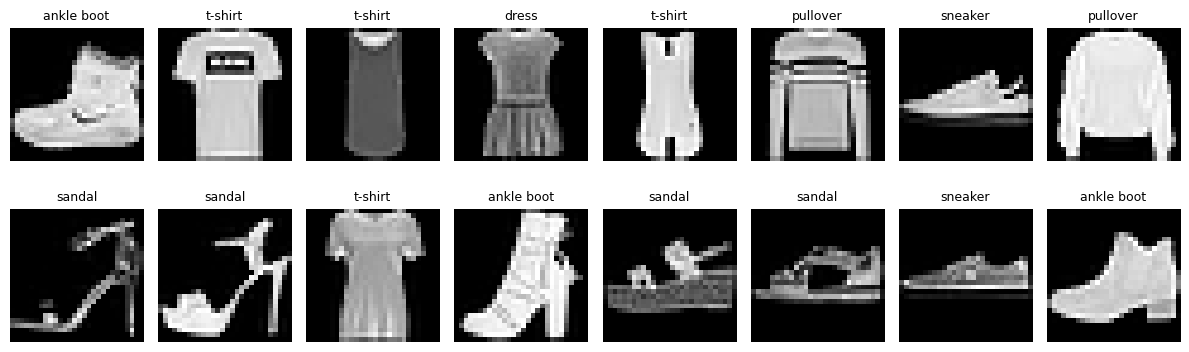

In [9]:
from matplotlib import pyplot as plt
fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    img = train_data[i][0]  # (1, 28, 28) → (28, 28)
    label = train_data[i][1]
    ax.imshow(img, cmap='gray')
    ax.set_title(labels[label], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [10]:
import time 
start_time = time.time()
for X, y in train_loader:
    pass
print(f"Time to iterate through the training set: {time.time() - start_time:.2f} seconds")

Time to iterate through the training set: 0.19 seconds


---

## Buổi 16

### hàm softmax 

Công thức:

$$\hat{y}_i = \frac{\exp(o_i)}{\sum_j \exp(o_j)}$$

In [11]:
import torch


def softmax(X):
    """
    Compute the softmax of a tensor.
        - Input: X of shape (batch_size, num_classes)
        - Output: softmax probabilities of the same shape
        - Numerical stability: subtract max from each row before exponentiating
    """
    X_exp = torch.exp(X)
    partition = X_exp.sum(dim=1, keepdim=True)
    return X_exp / partition  # The broadcasting mechanism is applied here


In [16]:
X = torch.randn(28, 28)
Y = softmax(X)
print(f"Input:\n{X}\n")
print(f"Softmax output:\n{Y}\n")
print(f"Sum of softmax probabilities (should be 1 for each row):\n{Y.sum(dim=1)}")

Input:
tensor([[-6.1482e-01,  8.8807e-01, -9.2089e-01,  7.2597e-02, -2.9989e-01,
         -7.7947e-01, -3.4354e-01, -4.3052e-01,  1.8740e-01, -2.3794e-01,
         -7.8785e-01, -2.2300e-02,  5.5650e-02,  8.9934e-01, -3.8301e-01,
          4.3681e-02, -8.5796e-01, -4.3626e-01, -8.1826e-02,  8.2129e-01,
         -6.1223e-01, -1.0700e+00,  7.0745e-01, -7.7387e-01, -5.5948e-01,
         -8.2595e-02,  1.1918e+00, -1.2194e+00],
        [ 1.2732e+00, -1.2160e+00, -1.2507e+00,  2.2121e+00, -1.6500e-01,
          1.4408e+00,  2.0202e-01,  8.8681e-01,  3.1393e-01,  6.6818e-01,
         -2.4526e-01, -7.7881e-01, -9.6618e-01, -6.8778e-03, -1.3132e+00,
          2.0796e+00,  7.9058e-01, -1.0621e+00, -9.6971e-04, -1.3836e+00,
         -1.3721e-01,  6.2631e-01,  1.7837e-01,  8.7173e-01, -2.1137e+00,
         -4.2921e-01, -1.8296e-01,  1.8431e+00],
        [ 1.2741e+00,  1.3925e+00,  6.2907e-01, -5.5036e-01,  1.3459e+00,
         -2.3548e+00,  1.8492e-01,  1.7345e+00,  6.4199e-01, -4.1916e-01,
       

In [17]:
X_shifted = X - X.max(dim=1, keepdim=True).values
X_exp = torch.exp(X_shifted)

In [18]:
X_flat = X.reshape(-1, 784)

In [19]:
class SoftmaxRegressionScratch:
    def __init__(self, num_inputs=784, num_outputs=10, lr=0.1, sigma=0.01):
        self.W = torch.normal(
            0, sigma, size=(num_inputs, num_outputs), requires_grad=True
        )
        self.b = torch.zeros(num_outputs, requires_grad=True)
        self.lr = lr

| Tham số      | Shape       | Giá trị khởi tạo       | Ý nghĩa                                     |
| ------------ | ----------- | ---------------------- | ------------------------------------------- |
| $\mathbf{W}$ | $(784, 10)$ | $\mathcal{N}(0, 0.01)$ | Ma trận trọng số: 784 features → 10 classes |
| $\mathbf{b}$ | $(10,)$     | $0$                    | Bias cho mỗi class                          |

- 784x10: input x output ~ 784 đặc trưng đầu vào, 10 class
- b = 10 ~ có 10 lớp đầu ra, mỗi lớp cần một intercept (biểu thị giá trị dự đoán ?) riêng 

### Tóm tắt nhanh (Q&A)

- Trong bài này có **10 classes** nên output có 10 logit.
- Vì vậy `W` có shape `(784, 10)` và `b` có shape `(10,)`.
- Tổng tham số: `784*10 + 10 = 7850`.
- `10` trong `W` chính là **số class đầu ra** (số cột của `W`).
- `b` không phải bằng 10, mà là **vector gồm 10 phần tử** (mỗi class một bias).
- Dạng chuẩn là `z = xW + b`.
- Có thể viết tương đương bằng cách gộp bias: `x_tilde = [x, 1]`, `W_tilde = [W; b]`, rồi `z = x_tilde W_tilde`.
- Không nên hiểu là `(x + 1)W` theo phép cộng thường.

In [20]:
# FORWARD pass


def forward(self, X):
    X = X.reshape(-1, self.W.shape[0])  # Flatten input ~ batch,1,28,28 -> batch,784
    return softmax(X @ self.W + self.b)

X (64, 1, 28, 28) 
  → reshape → (64, 784) 
  → matmul(X, W) → (64, 10)     # logits
  → + b → (64, 10)              # logits + bias
  → softmax → (64, 10)          # xác suất

### Pipeline Softmax Regression (tóm gọn 1 cell)

> [!NOTE] ELI5
> Mỗi ảnh 28x28 được duỗi thành 784 số. Model dùng các số này để chấm điểm cho 10 lớp quần áo, rồi đổi điểm thành xác suất.

1. **Input batch**: `X` có shape `(64, 1, 28, 28)`.
2. **Flatten**: `X -> X_flat` có shape `(64, 784)` vì $28\times 28=784$.
3. **Linear scores (logits)**: `Z = X_flat @ W + b` với:
   - `W` shape `(784, 10)`
   - `b` shape `(10,)`
   - `Z` shape `(64, 10)`
4. **Softmax**: `Y_hat = softmax(Z)` để đổi logits thành xác suất 10 lớp, mỗi hàng tổng bằng 1.

Công thức gọn:
$$\hat{Y}=\text{softmax}(X_{\text{flat}}W+b)$$

Tổng tham số học:
$$784\times 10 + 10 = 7850$$

In [21]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y]).mean()

## Training loop

In [22]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

In [26]:
# Data
transform = transforms.Compose(
    [
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
    ]
)

train_data = torchvision.datasets.FashionMNIST(
    root=".data", train=True, transform=transform, download=True
)
test_data = torchvision.datasets.FashionMNIST(
    root=".data", train=False, transform=transform, download=True
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [27]:
num_inputs = 28 * 28
num_outputs = 10
W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True) # mean=0, std=0.01, shape=(784, 10), requires_grad=True
b = torch.zeros(num_outputs, requires_grad=True) # shape=(10,), requires_grad=True
lr = 0.1

In [28]:
num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    total_acc = 0
    total_samples = 0

    for X, y in train_loader:
        X_flat = X.reshape(-1, num_inputs)  # Flatten input ~ batch,1,28,28 -> batch,784
        y_hat = softmax(X_flat @ W + b)  # 256,10
        loss = cross_entropy(y_hat, y)
        loss.backward()

        with torch.no_grad():
            W -= lr * W.grad
            b -= lr * b.grad

            W.grad.zero_()
            b.grad.zero_()

        total_loss += loss.item() * y.size(0)
        total_acc += (y_hat.argmax(dim=1) == y).sum().item()
        total_samples += y.size(0)
    train_loss = total_loss / total_samples
    train_acc = total_acc / total_samples
    print(
        f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}"
    )
    

Epoch 1/10, Loss: 0.6234, Accuracy: 0.7900
Epoch 2/10, Loss: 0.4907, Accuracy: 0.8320
Epoch 3/10, Loss: 0.4653, Accuracy: 0.8401
Epoch 4/10, Loss: 0.4487, Accuracy: 0.8456
Epoch 5/10, Loss: 0.4411, Accuracy: 0.8480
Epoch 6/10, Loss: 0.4344, Accuracy: 0.8514
Epoch 7/10, Loss: 0.4291, Accuracy: 0.8522
Epoch 8/10, Loss: 0.4264, Accuracy: 0.8534
Epoch 9/10, Loss: 0.4209, Accuracy: 0.8552
Epoch 10/10, Loss: 0.4180, Accuracy: 0.8557


In [29]:
correct = 0
total = 0
with torch.no_grad():
    for X, y in test_loader:
        X_flat = X.reshape(-1, num_inputs)
        y_hat = softmax(X_flat @ W + b)
        correct += (y_hat.argmax(dim=1) == y).sum().item()
        total += y.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8283


In [30]:
labels_map = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

X_test, y_test = next(iter(test_loader))
X_flat = X_test.reshape(-1, num_inputs)
y_hat = softmax(torch.matmul(X_flat, W) + b)
preds = y_hat.argmax(dim=1)

# Lọc ảnh sai
wrong_mask = preds != y_test
wrong_X = X_test[wrong_mask]
wrong_true = y_test[wrong_mask]
wrong_pred = preds[wrong_mask]

# In ra 5 ảnh đầu tiên bị sai
for i in range(min(5, len(wrong_X))):
    true_label = labels_map[wrong_true[i]]
    pred_label = labels_map[wrong_pred[i]]
    print(f"True: {true_label:12s} | Predicted: {pred_label}")

True: sneaker      | Predicted: sandal
True: coat         | Predicted: pullover
True: pullover     | Predicted: shirt
True: ankle boot   | Predicted: sneaker
True: coat         | Predicted: pullover


In [31]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

# ====== FUNCTIONS ======
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(dim=1, keepdim=True)
    return X_exp / partition

def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y]).mean()

# ====== DATA ======
trans = transforms.Compose([transforms.ToTensor()])
train_data = torchvision.datasets.FashionMNIST(
    './data', train=True, transform=trans, download=True)
test_data = torchvision.datasets.FashionMNIST(
    './data', train=False, transform=trans, download=True)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=256, shuffle=False)

# ====== MODEL ======
num_inputs, num_outputs, lr = 784, 10, 0.1
W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

# ====== TRAIN ======
for epoch in range(10):
    for X, y in train_loader:
        y_hat = softmax(X.reshape(-1, num_inputs) @ W + b)
        loss = cross_entropy(y_hat, y)
        loss.backward()
        with torch.no_grad():
            W -= lr * W.grad;  b -= lr * b.grad
            W.grad.zero_();    b.grad.zero_()

# ====== EVALUATE ======
correct, total = 0, 0
with torch.no_grad():
    for X, y in test_loader:
        y_hat = softmax(X.reshape(-1, num_inputs) @ W + b)
        correct += (y_hat.argmax(1) == y).sum().item()
        total += y.shape[0]
print(f"Test Accuracy: {correct/total:.2%}")


 15%|█▍        | 3.83M/26.4M [00:15<01:29, 251kB/s] 


KeyboardInterrupt: 